<a href="https://colab.research.google.com/github/muhovicemir/Research-Methods-in-Computer-Science-DVA463/blob/main/INL2/INL2_visualization_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Programmer   IDE-A   IDE-B  Prog-1_time  Prog-2_time  IDE-A_time  IDE-B_time
0           1  Prog-1  Prog-2          104         71.3       104.0        71.3
1           2  Prog-2  Prog-1          102        110.0       110.0       102.0
2           3  Prog-1  Prog-2          159        178.0       159.0       178.0
3           4  Prog-1  Prog-2          168        153.0       168.0       153.0
4           5  Prog-2  Prog-1          150        120.0       120.0       150.0
5           6  Prog-2  Prog-1          151        174.0       174.0       151.0
6           7  Prog-1  Prog-2          111         94.9       111.0        94.9
7           8  Prog-2  Prog-1          105         86.1        86.1       105.0
8           9  Prog-1  Prog-2          137        115.0       137.0       115.0
9          10  Prog-2  Prog-1          124        175.0       175.0       124.0
Mean IDE-A time: 134.41 minutes
Mean IDE-B time: 124.42 minutes
Median IDE-A time: 128.5
Median IDE-B time: 119.5
IDE-A:

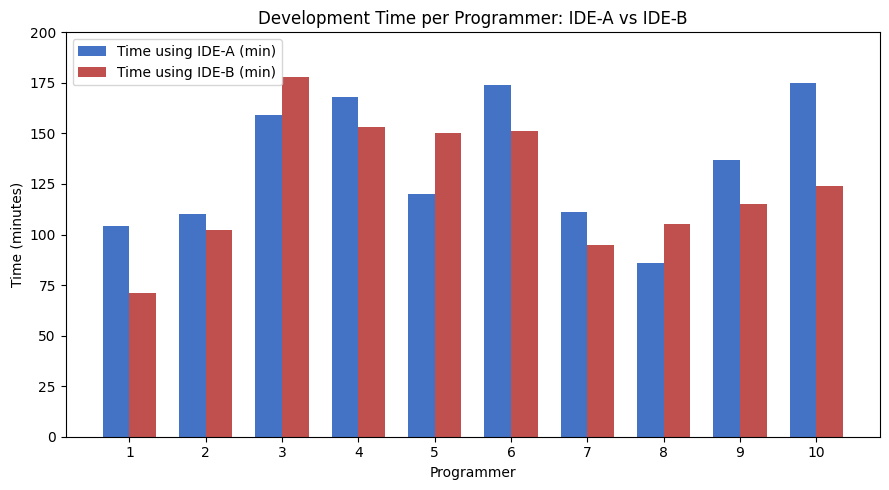

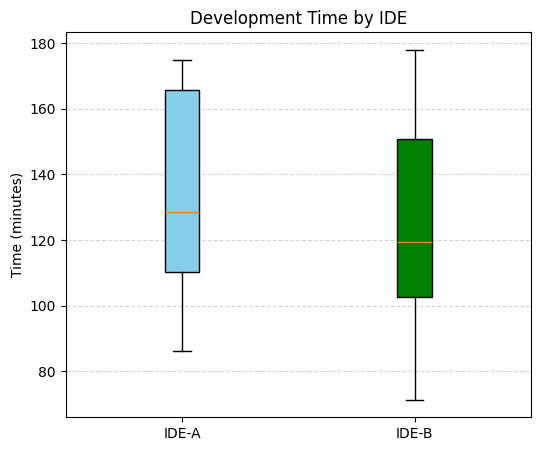

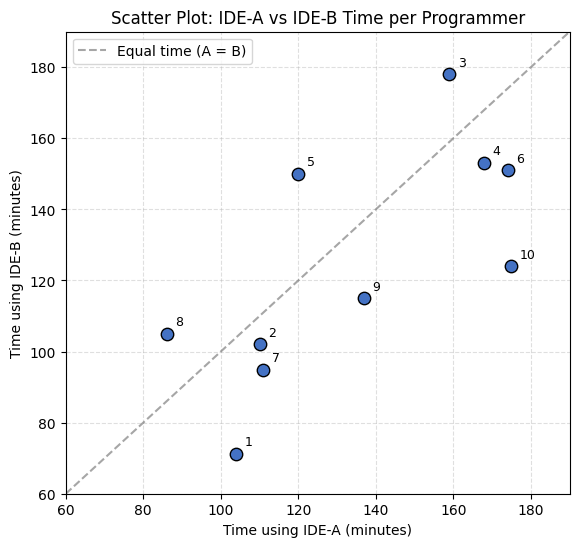

Paired t-test: t = 1.2389, p-value = 0.2467


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.width', 200)

assignment_table = pd.DataFrame({
    "Programmer": list(range(1, 11)),
    "IDE-A": ["Prog-1", "Prog-2", "Prog-1", "Prog-1", "Prog-2", "Prog-2", "Prog-1", "Prog-2", "Prog-1", "Prog-2"],
    "IDE-B": ["Prog-2", "Prog-1", "Prog-2", "Prog-2", "Prog-1", "Prog-1", "Prog-2", "Prog-1", "Prog-2", "Prog-1"],
})

data_table = pd.DataFrame({
    "Programmer": list(range(1, 11)),
    "Prog-1_time": [104, 102, 159, 168, 150, 151, 111, 105, 137, 124],
    "Prog-2_time": [71.3, 110, 178, 153, 120, 174, 94.9, 86.1, 115, 175],
})

df = pd.merge(assignment_table, data_table, on='Programmer')

df['IDE-A_time'] = df.apply(lambda row: row[row['IDE-A'] + '_time'], axis=1)
df['IDE-B_time'] = df.apply(lambda row: row[row['IDE-B'] + '_time'], axis=1)

print(df)

mean_a = df['IDE-A_time'].mean()
mean_b = df['IDE-B_time'].mean()
median_a = df['IDE-A_time'].median()
median_b = df['IDE-B_time'].median()
min_a, max_a = df['IDE-A_time'].min(), df['IDE-A_time'].max()
min_b, max_b = df['IDE-B_time'].min(), df['IDE-B_time'].max()
std_a = df['IDE-A_time'].std()
std_b = df['IDE-B_time'].std()

print("Mean IDE-A time:", mean_a, "minutes")
print("Mean IDE-B time:", mean_b, "minutes")
print("Median IDE-A time:", median_a)
print("Median IDE-B time:", median_b)
print(f"IDE-A: Min: {min_a:.2f}, Max: {max_a:.2f}")
print(f"IDE-B: Min: {min_b:.2f}, Max: {max_b:.2f}")
print("Std IDE-A time:", std_a)
print("Std IDE-B time:", std_b)

# Development Time per Programmer
x = np.arange(1, 11)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, df['IDE-A_time'], width, label='Time using IDE-A (min)', color='#4472C4')
ax.bar(x + width/2, df['IDE-B_time'], width, label='Time using IDE-B (min)', color='#C0504D')
ax.set_xlabel('Programmer')
ax.set_ylabel('Time (minutes)')
ax.set_title('Development Time per Programmer: IDE-A vs IDE-B')
ax.set_xticks(x)
ax.legend()
ax.set_ylim(0, 200)
plt.tight_layout()
plt.savefig('bar_chart.png', dpi=150)
plt.show()

# Box plot
plt.figure(figsize=(6, 5))
box = plt.boxplot([df['IDE-A_time'], df['IDE-B_time']], tick_labels=['IDE-A', 'IDE-B'], patch_artist=True)
colors = ['skyblue', 'green']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
plt.title('Development Time by IDE')
plt.ylabel('Time (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('boxplot.png', dpi=150)
plt.show()

# Scatter plot
plt.figure(figsize=(6.5, 6))
plt.scatter(df['IDE-A_time'], df['IDE-B_time'], color='#4472C4', edgecolor='black', s=80, zorder=3)

for i, row in df.iterrows():
    plt.annotate(str(row['Programmer']), (row['IDE-A_time'], row['IDE-B_time']),
                 textcoords="offset points", xytext=(6, 6), fontsize=9)

lims = [60, 190]
plt.plot(lims, lims, linestyle='--', color='gray', alpha=0.7, label='Equal time (A = B)')
plt.xlim(lims)
plt.ylim(lims)
plt.title('Scatter Plot: IDE-A vs IDE-B Time per Programmer')
plt.xlabel('Time using IDE-A (minutes)')
plt.ylabel('Time using IDE-B (minutes)')
plt.legend()
plt.grid(linestyle='--', alpha=0.4)
plt.savefig('scatter_plot.png', dpi=150)
plt.show()

# Paired t-test
t_stat, t_pvalue = stats.ttest_rel(df['IDE-A_time'], df['IDE-B_time'])
print(f"Paired t-test: t = {t_stat:.4f}, p-value = {t_pvalue:.4f}")